# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

El objetivo central de este proyecto es determinar, mediante pruebas estadísticas, cuál de los planes de servicio, "Surf" o "Ultimate", genera mayores ingresos para la compañía.

Metodología y Pasos Principales

La ejecución del proyecto se desarrollará a través de las siguientes fases:

1. Exploración y Limpieza de Datos: Revisar y depurar cada conjunto de datos para asegurar su calidad y consistencia.

2. Integración de Datos: Fusionar los datasets para crear un único dataframe que consolide la información de cada usuario: cantidad de llamadas, minutos consumidos, mensajes enviados y megabytes (MB) utilizados.

3. Cálculo de Ingresos: Determinar el ingreso total generado por cada cliente, considerando las tarifas base de su respectivo plan y los cargos adicionales por el uso excedente de los servicios.

4. Análisis Exploratorio de Datos (EDA): Generar visualizaciones (gráficos) para identificar patrones de comportamiento de los usuarios en relación con las características de sus planes.

5. Pruebas Estadísticas: Aplicar las pruebas pertinentes para validar la hipótesis sobre la diferencia de ingresos entre los planes "Surf" y "Ultimate".

## Inicialización

In [50]:
# Cargar todas las librerías
import numpy as np
import pandas as pd
import math as mt
import seaborn as sns
from matplotlib import pyplot as plt
from math import factorial
from scipy import stats as st

## Cargar datos

In [51]:
# Carga los archivos de datos en diferentes DataFrames

df_tarifas = pd.read_csv('megaline_plans.csv')
df_usuarios = pd.read_csv('megaline_users.csv')
df_llamadas = pd.read_csv('megaline_calls.csv')
df_mensajes = pd.read_csv('megaline_messages.csv')
df_internet = pd.read_csv('megaline_internet.csv')


## Preparar los datos

Para la preparacion de los datos realice una primera visualizacion de los mismos con el metodo head() y para darme un aidea general de la estructura y los tipos de datos y la existencia de nulos use el metodo info()

## Tarifas

In [52]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_tarifas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [53]:
# Imprime una muestra de los datos para las tarifas
df_tarifas.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


En este dataframe no veo informacion que este incorrecta, tampoco veo datos faltantes y no considero que sea necesario hacer ninguna modificacion ya que son las caracteristicas generales de cada plan y los datos estan completos.

## Corregir datos

No hay datos que se deban corregir en este DF

## Enriquecer los datos

No considero que sea necesario agregar nada mas en este DF.

## Usuarios/as

In [54]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
df_usuarios.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [55]:
# Imprime una muestra de datos para usuarios
df_usuarios.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


En este conjunto de datos veo que es la infromacion personal e informacion del plan de datos de los usuarios, veo algunos datos nulos en la columna de churn_date pero seguramente se deben a que el plan seguia en uso, los tipos de dato coinciden con la infromacion en el DF, sin embargo cambiaria el tipo de dato de la columan a reg_date al tipo de dato de fecha para hacer mas facil el consultar la infromacion mensual de los usuarios.

### Corregir los datos

Me asegure que no existieran datos duplicados y realice el cambio de la fecha de registro al tipo de dato fecha en pandas.

In [56]:
# Buscar duplicados en los datos 
print(df_usuarios.duplicated().sum())
print(df_usuarios.duplicated(subset=['user_id']).sum()) 

# Transformar la columna 'reg_date' a formato datetime
df_usuarios['reg_date'] = pd.to_datetime(df_usuarios['reg_date'])

# Mostrar los tipos de datos para verificar la transformación
df_usuarios.info()
df_usuarios.head()

0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


### Enriquecer los datos

Agregue una columna adicional para el periodo mes-año de cada usuario para facilitar el calculo de los ingresos totales.

In [57]:
# Crear la nueva columna 'month' extrayendo el mes
df_usuarios['month'] = df_usuarios['reg_date'].dt.to_period('M')
df_usuarios.info()
df_usuarios.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
 8   month       500 non-null    period[M]     
dtypes: datetime64[ns](1), int64(2), object(5), period[M](1)
memory usage: 35.3+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,2018-12
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,2018-08
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN,2018-10
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN,2018-01
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN,2018-05


## Llamadas

In [58]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
df_llamadas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [59]:
# Imprime una muestra de datos para las llamadas
df_llamadas.head()


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Para este conjunto de datos veo que es la informacion de la duracion de las llamadas de cada usuario y la fecha en la que realizaron dicha llamada, no hay datos nulos, el tipo de dato en cada columna coincide con el tipo de dato que contien el DF solo cambiaria la fecha al tipo de dato de fecha en pandas

### Corregir los datos

Me asegure que no existieran datos duplicados y realice el cambio de la fecha de registro al tipo de dato fecha en pandas.

In [60]:
# Buscar duplicados en los datos 
print(df_llamadas.duplicated().sum())
print(df_llamadas.duplicated(subset=['id']).sum())

# Transformar la columna 'reg_date' a formato datetime
df_llamadas['call_date'] = pd.to_datetime(df_llamadas['call_date'])

# Mostrar los tipos de datos para verificar la transformación
df_llamadas.info()
df_llamadas.head()

0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


### Enriquecer los datos

Agregue una columna adicional para el periodo mes-año de cada usuario para facilitar el calculo de los ingresos totales.

In [61]:
# Crear la nueva columna 'month' extrayendo el mes
df_llamadas['month'] = df_llamadas['call_date'].dt.to_period('M')
df_llamadas.info()
df_llamadas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
 4   month      137735 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 5.3+ MB


,id,user_id,call_date,duration,month
0,1000_93,1000,2018-12-27,8.52,2018-12
1,1000_145,1000,2018-12-27,13.66,2018-12
2,1000_247,1000,2018-12-27,14.48,2018-12
3,1000_309,1000,2018-12-28,5.76,2018-12
4,1000_380,1000,2018-12-30,4.22,2018-12


## Mensajes

In [62]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
df_mensajes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [63]:
# Imprime una muestra de datos para los mensajes
df_mensajes.head()


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


Para este conjunto de datos veo que es la informacion de los mensajes que cada usuario mando y la fecha en la que envio dicha mensaje, no hay datos nulos, el tipo de dato en cada columna coincide con el tipo de dato que contien el DF solo cambiaria la fecha al tipo de dato de fecha en pandas

### Corregir los datos

Me asegure que no existieran datos duplicados y realice el cambio de la fecha de registro al tipo de dato fecha en pandas.

In [64]:
# Buscar duplicados en los datos 
print(df_mensajes.duplicated().sum())
print(df_mensajes.duplicated(subset=['id']).sum())

# Transformar la columna 'reg_date' a formato datetime
df_mensajes['message_date'] = pd.to_datetime(df_mensajes['message_date'])

# Mostrar los tipos de datos para verificar la transformación
df_mensajes.info()
df_mensajes.head()

0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


### Enriquecer los datos

Agregue una columna adicional para el periodo mes-año de cada usuario para facilitar el calculo de los ingresos totales.

In [65]:
# Crear la nueva columna 'month' extrayendo el mes
df_mensajes['month'] = df_mensajes['message_date'].dt.to_period('M')
df_mensajes.info()
df_mensajes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(1), period[M](1)
memory usage: 2.3+ MB


,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,2018-12
1,1000_160,1000,2018-12-31,2018-12
2,1000_223,1000,2018-12-31,2018-12
3,1000_251,1000,2018-12-27,2018-12
4,1000_255,1000,2018-12-26,2018-12


## Internet

In [66]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [67]:
# Imprime una muestra de datos para el tráfico de internet
df_internet.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


Para este conjunto de datos veo que es la informacion de la cantidad de mb que cada usuario consumio y la fecha en la que realizaron dicho consumo, no hay datos nulos, el tipo de dato en cada columna coincide con el tipo de dato que contien el DF solo cambiaria la fecha al tipo de dato de fecha en pandas

### Corregir los datos

Me asegure que no existieran datos duplicados y realice el cambio de la fecha de registro al tipo de dato fecha en pandas.

In [68]:
# Buscar duplicados en los datos 
print(df_internet.duplicated().sum())
print(df_internet.duplicated(subset=['id']).sum())

# Transformar la columna 'reg_date' a formato datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

# Mostrar los tipos de datos para verificar la transformación
df_internet.info()
df_internet.head()

0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


### Enriquecer los datos

Agregue una columna adicional para el periodo mes-año de cada usuario para facilitar el calculo de los ingresos totales.

In [69]:
# Crear la nueva columna 'month' extrayendo el mes
df_internet['month'] = df_internet['session_date'].dt.to_period('M')
df_internet.info()
df_internet.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 4.0+ MB


,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,2018-12
1,1000_204,1000,2018-12-31,0.00,2018-12
2,1000_379,1000,2018-12-28,660.40,2018-12
3,1000_413,1000,2018-12-26,270.99,2018-12
4,1000_442,1000,2018-12-27,880.22,2018-12


## Estudiar las condiciones de las tarifas

A los usuarios se les cobra una tarifa base dependiendo del plan y adicional a esa tarifa se les cobra un adicional si superaron lo establecido en cada plan con realacion a la cantidad de minutos, mensajes y mb.

In [70]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
df_tarifas.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

Para este paso agrupe cada DF para obtener la infromacion del numero de llamadas, duracion de las llamadas, numero de mensajes y cantidad de mb usados por mes y por usuario utilizando el metodo groupby.

In [71]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
llamadas_por_usuario = df_llamadas.groupby(['user_id', 'month']).size().reset_index(name='calls')
print(llamadas_por_usuario.head())

# Verificar que tengo datos para todos los meses
print(llamadas_por_usuario['month'].unique())

# Verificar que no hay valores nulos
print(llamadas_por_usuario.isnull().sum())


   user_id    month  calls
0     1000  2018-12     16
1     1001  2018-08     27
2     1001  2018-09     49
3     1001  2018-10     65
4     1001  2018-11     64
<PeriodArray>
['2018-12', '2018-08', '2018-09', '2018-10', '2018-11', '2018-05', '2018-06',
 '2018-07', '2018-03', '2018-04', '2018-01', '2018-02']
Length: 12, dtype: period[M]
user_id    0
month      0
calls      0
dtype: int64


In [72]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
#1. Aplicar la regla de negocio: redondear cada llamada individual al minuto superior
df_llamadas['duration'] = np.ceil(df_llamadas['duration'])

# 2. Ahora sí, calcular la cantidad de minutos usados por cada usuario al mes
minutos_por_usuario = df_llamadas.groupby(['user_id', 'month'])['duration'].sum().reset_index(name='minutes')

# Visualizar el resultado
print(minutos_por_usuario.head())

   user_id    month  minutes
0     1000  2018-12    124.0
1     1001  2018-08    182.0
2     1001  2018-09    315.0
3     1001  2018-10    393.0
4     1001  2018-11    426.0


In [73]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
mensajes_por_usuario = df_mensajes.groupby(['user_id', 'month']).size().reset_index(name='messages')
print(mensajes_por_usuario.head())


   user_id    month  messages
0     1000  2018-12        11
1     1001  2018-08        30
2     1001  2018-09        44
3     1001  2018-10        53
4     1001  2018-11        36


In [74]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
mb_por_usuario = df_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index(name='mb_used')
print(mb_por_usuario.head())

# Verificar que tengo datos para todos los meses
print(mb_por_usuario['month'].unique())

# Verificar que no hay valores nulos
print(mb_por_usuario.isnull().sum())



   user_id    month   mb_used
0     1000  2018-12   1901.47
1     1001  2018-08   6919.15
2     1001  2018-09  13314.82
3     1001  2018-10  22330.49
4     1001  2018-11  18504.30
<PeriodArray>
['2018-12', '2018-08', '2018-09', '2018-10', '2018-11', '2018-05', '2018-06',
 '2018-07', '2018-03', '2018-04', '2018-02', '2018-01']
Length: 12, dtype: period[M]
user_id    0
month      0
mb_used    0
dtype: int64


Junte la informacion de los DF que genere en el paso anterior en un solo DF utilizando el metodo merge para tener reunida toda la infromacion por usuario, por mes de la cantidad de llamadas, duracion de la llamada, mensajes y mb usados en un solo DF.

In [75]:

# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
datos_usuarios = llamadas_por_usuario.merge(minutos_por_usuario, on=['user_id', 'month'], how='outer')

datos_usuarios = datos_usuarios.merge(mensajes_por_usuario, on=['user_id', 'month'], how='outer')

datos_usuarios = datos_usuarios.merge(mb_por_usuario, on=['user_id', 'month'], how='outer')

print(datos_usuarios.head())
datos_usuarios = datos_usuarios.fillna(0)
datos_usuarios.info()
print(datos_usuarios.tail())

# Verificar que tienes todos los meses
print("\nMeses únicos:")
print(sorted(datos_usuarios['month'].unique()))

# Verificar que tienes todos los usuarios
print("\nNúmero de usuarios únicos:", datos_usuarios['user_id'].nunique())


   user_id    month  calls  minutes  messages   mb_used
0     1000  2018-12   16.0    124.0      11.0   1901.47
1     1001  2018-08   27.0    182.0      30.0   6919.15
2     1001  2018-09   49.0    315.0      44.0  13314.82
3     1001  2018-10   65.0    393.0      53.0  22330.49
4     1001  2018-11   64.0    426.0      36.0  18504.30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype    
---  ------    --------------  -----    
 0   user_id   2293 non-null   int64    
 1   month     2293 non-null   period[M]
 2   calls     2293 non-null   float64  
 3   minutes   2293 non-null   float64  
 4   messages  2293 non-null   float64  
 5   mb_used   2293 non-null   float64  
dtypes: float64(4), int64(1), period[M](1)
memory usage: 107.6 KB
      user_id    month  calls  minutes  messages   mb_used
2288     1498  2018-12   39.0    339.0       0.0  23137.69
2289     1499  2018-09   41.0    346.0       0

In [76]:
# Verificar cuántos usuarios hay en la tabla original
print("Usuarios en la tabla 'users':", df_usuarios['user_id'].nunique())
print("Total de filas en 'users':", len(df_usuarios))

# Ver si hay duplicados
print("¿Hay user_id duplicados?", df_usuarios['user_id'].duplicated().any())

Usuarios en la tabla 'users': 500
Total de filas en 'users': 500
¿Hay user_id duplicados? False


In [77]:
# Verificar usuarios únicos en cada DataFrame
print("Usuarios en user_calls:", df_llamadas['user_id'].nunique()) 
print("Usuarios en user_messages:", df_mensajes['user_id'].nunique())
print("Usuarios en user_internet:", df_internet['user_id'].nunique())

# Verificar el DataFrame fusionado
print("Usuarios en user_data (fusionado):", datos_usuarios['user_id'].nunique())

Usuarios en user_calls: 481
Usuarios en user_messages: 402
Usuarios en user_internet: 489
Usuarios en user_data (fusionado): 490


In [78]:
# Añade la información de la tarifa
user_data = datos_usuarios.merge(df_usuarios[['user_id', 'plan']], on='user_id', how='left') \
                     .merge(df_tarifas, left_on='plan', right_on='plan_name', how='left')
                     
user_data.tail()

,user_id,month,calls,minutes,messages,mb_used,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
2288,1498,2018-12,39.0,339.0,0.0,23137.69,surf,50,15360,500,20,10,0.03,0.03,surf
2289,1499,2018-09,41.0,346.0,0.0,12984.76,surf,50,15360,500,20,10,0.03,0.03,surf
2290,1499,2018-10,53.0,385.0,0.0,19492.43,surf,50,15360,500,20,10,0.03,0.03,surf
2291,1499,2018-11,45.0,308.0,0.0,16813.83,surf,50,15360,500,20,10,0.03,0.03,surf
2292,1499,2018-12,65.0,496.0,0.0,22059.21,surf,50,15360,500,20,10,0.03,0.03,surf


El cálculo del ingreso mensual para cada usuario se determina sumando la cuota mensual fija del plan a los cargos por exceso de uso. Primero, se cuantifica el uso extra de minutos y mensajes, utilizando np.maximum(0, uso - límite) para asegurar que solo se consideren los valores positivos que superan la asignación del plan. Para los datos, los megabytes usados se convierten a gigabytes y se redondean hacia arriba (np.ceil) para capturar la política de cobro por fracción de GB. Finalmente, el ingreso total (monthly_revenue) resulta de la suma de la cuota base (usd_monthly_pay) y los costos generados por cada exceso (cost_extra_minutes, cost_extra_messages, cost_extra_gb).

In [79]:
# Calcula el ingreso mensual para cada usuario

# Calcular minutos extra (solo si excede el límite)
user_data['extra_minutes'] = np.maximum(0, user_data['minutes'] - user_data['minutes_included'])

# Calcular SMS extra
user_data['extra_messages'] = np.maximum(0, user_data['messages'] - user_data['messages_included'])

# Calcular GB extra (convertir MB a GB y redondear hacia arriba)
user_data['gb_used'] = np.ceil(user_data['mb_used'] / 1024)  
user_data['gb_included'] = user_data['mb_per_month_included'] / 1024
user_data['extra_gb'] = np.maximum(0, user_data['gb_used'] - user_data['gb_included'])

# Costo por minutos extra
user_data['cost_extra_minutes'] = user_data['extra_minutes'] * user_data['usd_per_minute']

# Costo por SMS extra  
user_data['cost_extra_messages'] = user_data['extra_messages'] * user_data['usd_per_message']

# Costo por GB extra
user_data['cost_extra_gb'] = user_data['extra_gb'] * user_data['usd_per_gb']

# Ingreso total = cuota fija + todos los excesos
user_data['monthly_revenue'] = (user_data['usd_monthly_pay'] + 
                               user_data['cost_extra_minutes'] + 
                               user_data['cost_extra_messages'] + 
                               user_data['cost_extra_gb'])

user_data.head()


,user_id,month,calls,minutes,messages,mb_used,plan,messages_included,mb_per_month_included,minutes_included,...,plan_name,extra_minutes,extra_messages,gb_used,gb_included,extra_gb,cost_extra_minutes,cost_extra_messages,cost_extra_gb,monthly_revenue
0,1000,2018-12,16.0,124.0,11.0,1901.47,ultimate,1000,30720,3000,...,ultimate,0.0,0.0,2.0,30.0,0.0,0.0,0.00,0.0,70.00
1,1001,2018-08,27.0,182.0,30.0,6919.15,surf,50,15360,500,...,surf,0.0,0.0,7.0,15.0,0.0,0.0,0.00,0.0,20.00
2,1001,2018-09,49.0,315.0,44.0,13314.82,surf,50,15360,500,...,surf,0.0,0.0,14.0,15.0,0.0,0.0,0.00,0.0,20.00
3,1001,2018-10,65.0,393.0,53.0,22330.49,surf,50,15360,500,...,surf,0.0,3.0,22.0,15.0,7.0,0.0,0.09,70.0,90.09
4,1001,2018-11,64.0,426.0,36.0,18504.30,surf,50,15360,500,...,surf,0.0,0.0,19.0,15.0,4.0,0.0,0.00,40.0,60.00


## Estudia el comportamiento de usuario

### Llamadas

Duración promedio por plan y mes:
        plan    month     minutes
0       surf  2018-01  203.000000
1       surf  2018-02  297.000000
2       surf  2018-03  330.000000
3       surf  2018-04  351.540000
4       surf  2018-05  399.584416
5       surf  2018-06  431.298969
6       surf  2018-07  449.983471
7       surf  2018-08  410.111111
8       surf  2018-09  414.226804
9       surf  2018-10  429.729958
10      surf  2018-11  423.325088
11      surf  2018-12  473.836478
12  ultimate  2018-01  193.500000
13  ultimate  2018-02  403.142857
14  ultimate  2018-03  304.250000
15  ultimate  2018-04  336.857143
16  ultimate  2018-05  406.241379
17  ultimate  2018-06  370.957447
18  ultimate  2018-07  427.067797
19  ultimate  2018-08  421.436620
20  ultimate  2018-09  437.511628
21  ultimate  2018-10  450.735849
22  ultimate  2018-11  445.196850
23  ultimate  2018-12  459.099338


<Figure size 1400x800 with 0 Axes>

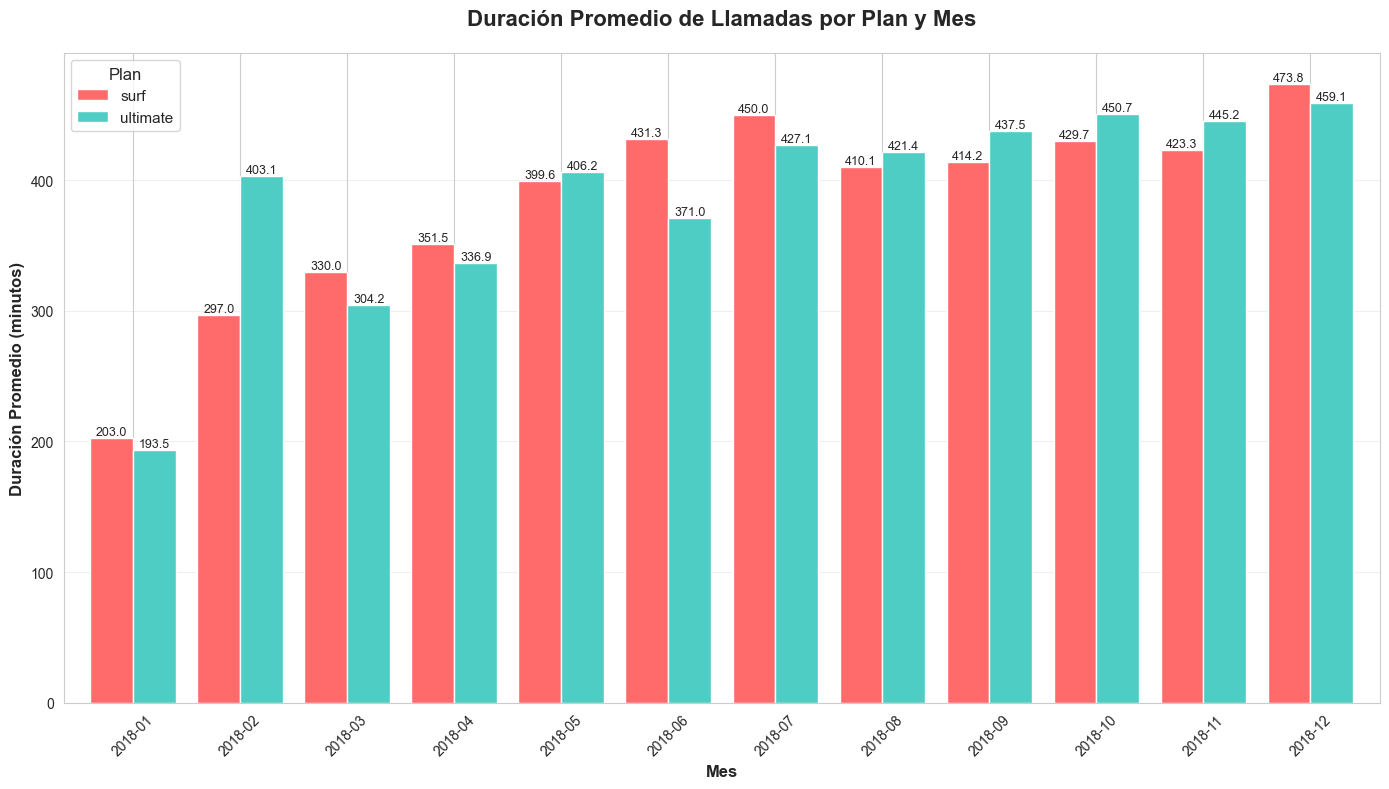

In [80]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
# Agrupar por plan y mes, calcular duración promedio
avg_duration = user_data.groupby(['plan', 'month'])['minutes'].mean().reset_index()

# Ver el resultado
print("Duración promedio por plan y mes:")
print(avg_duration.head(24))


# Configurar el estilo
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Crear gráfico de barras agrupadas
avg_duration_pivot = avg_duration.pivot(index='month', columns='plan', values='minutes')

# Crear el gráfico
ax = avg_duration_pivot.plot(kind='bar', 
                            figsize=(14, 8),
                            color=['#FF6B6B', '#4ECDC4'],  
                            width=0.8)

# Personalizar el gráfico
plt.title('Duración Promedio de Llamadas por Plan y Mes', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mes', fontsize=12, fontweight='bold')
plt.ylabel('Duración Promedio (minutos)', fontsize=12, fontweight='bold')
plt.legend(title='Plan', title_fontsize=12, fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.tight_layout()
plt.show()


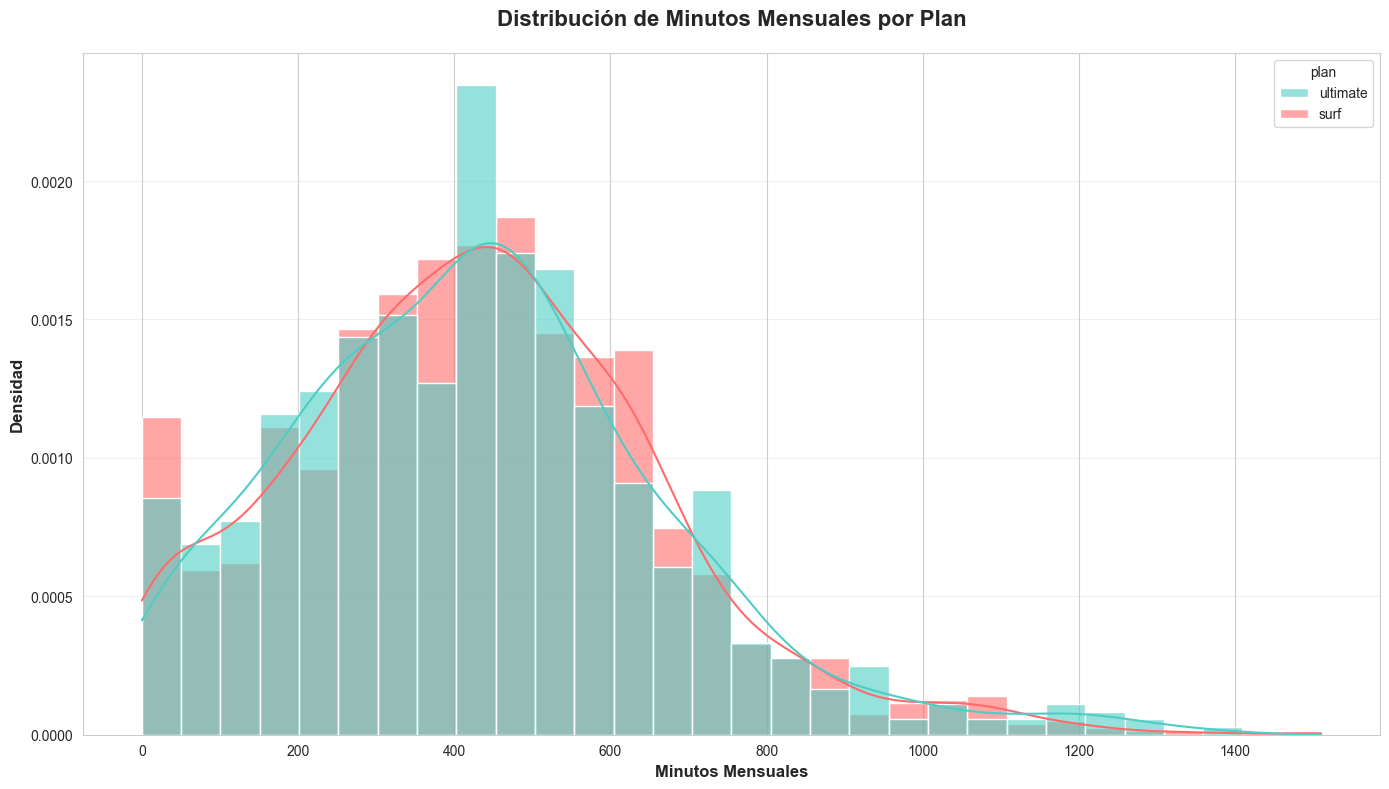

In [81]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

plt.figure(figsize=(14, 8))

# Histograma con curvas de densidad
sns.histplot(data=user_data, x='minutes', hue='plan', 
             bins=30, kde=True, stat='density', common_norm=False,
             palette={'surf': '#FF6B6B', 'ultimate': '#4ECDC4'}, 
             alpha=0.6)

plt.title('Distribución de Minutos Mensuales por Plan', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Minutos Mensuales', fontsize=12, fontweight='bold')
plt.ylabel('Densidad', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El patrón de uso mensual promedio de minutos de llamada es muy similar para ambos planes, con una media cercana a los 405 minutos y una variabilidad similar.

In [82]:
# Calcula la media y la varianza de la duración mensual de llamadas.
stats_by_plan_minutes = user_data.groupby('plan')['minutes'].agg([
    'count',   
    'mean',     
    'var',      
    'std',      
    'min',      
    'max'       
]).round(2)

print("Resumen estadístico:")
print(stats_by_plan_minutes)


Resumen estadístico:
          count    mean       var     std  min     max
plan                                                  
surf       1573  428.75  54968.28  234.45  0.0  1510.0
ultimate    720  430.45  57844.46  240.51  0.0  1369.0


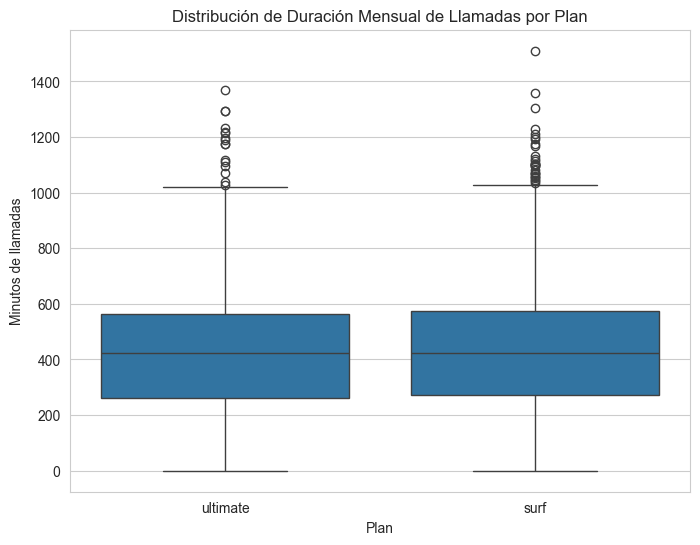

In [83]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(8, 6))
sns.boxplot(data=user_data, x='plan', y='minutes')
plt.title('Distribución de Duración Mensual de Llamadas por Plan')
plt.xlabel('Plan')
plt.ylabel('Minutos de llamadas')
plt.show()

A pesar de que el plan Surf es mucho más popular (con más del doble de clientes) que el plan Ultimate, el resumen estadístico y los gráficos de distribución muestran que el patrón de uso mensual promedio de minutos de llamada es muy similar para ambos planes, con una media cercana a los 405 minutos y una variabilidad similar. Además, los promedios mensuales de llamadas para ambos planes mostraron un crecimiento constante y notable a lo largo de 2018, comenzando en menos de 200 minutos en enero y terminando por encima de 430 minutos en diciembre, con el plan Surf liderando el uso promedio en la segunda mitad del año.

### Mensajes

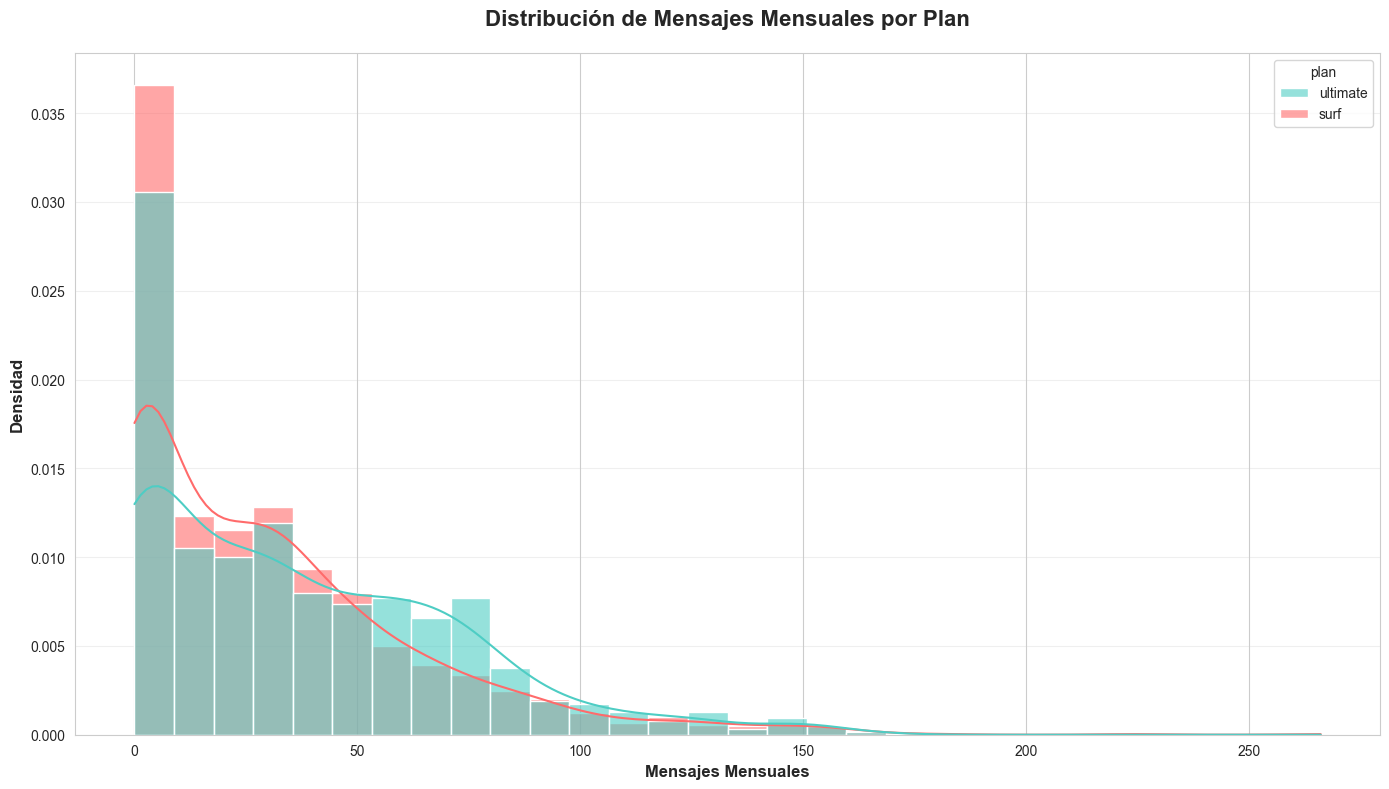

In [84]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
plt.figure(figsize=(14, 8))

# Histograma con curvas de densidad
sns.histplot(data=user_data, x='messages', hue='plan', 
             bins=30, kde=True, stat='density', common_norm=False,
             palette={'surf': '#FF6B6B', 'ultimate': '#4ECDC4'}, 
             alpha=0.6)

plt.title('Distribución de Mensajes Mensuales por Plan', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mensajes Mensuales', fontsize=12, fontweight='bold')
plt.ylabel('Densidad', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [85]:
# Calcula la media y la varianza de la cantidad mensual de mensajes.
stats_by_plan_messages = user_data.groupby('plan')['messages'].agg([
    'count',   
    'mean',     
    'var',      
    'std',      
    'min',      
    'max'       
]).round(2)

print("Resumen estadístico:")
print(stats_by_plan_messages)


Resumen estadístico:
          count   mean      var    std  min    max
plan                                              
surf       1573  31.16  1126.72  33.57  0.0  266.0
ultimate    720  37.55  1208.76  34.77  0.0  166.0


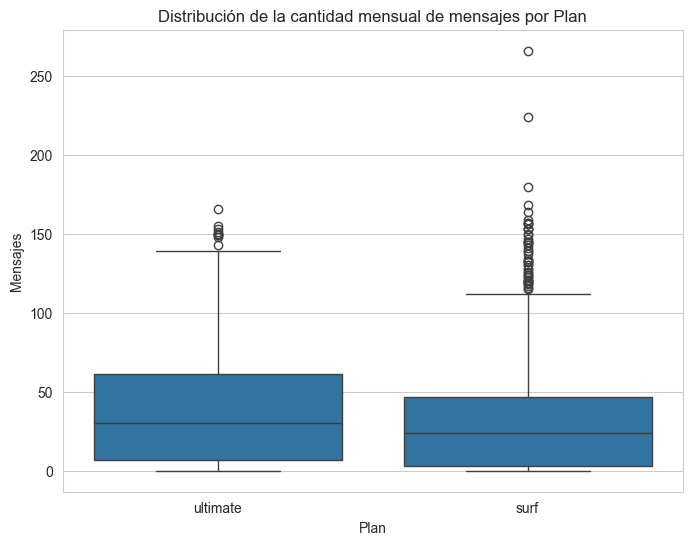

In [86]:
# Traza un diagrama de caja para visualizar la distribución de la cantidad mensual de mensajes
plt.figure(figsize=(8, 6))
sns.boxplot(data=user_data, x='plan', y='messages')
plt.title('Distribución de la cantidad mensual de mensajes por Plan')
plt.xlabel('Plan')
plt.ylabel('Mensajes')
plt.show()

El plan ultimate muestra un mayor uso promedio de mensajes mensuales que el plan surf, aunque el plan surf tiene más observaciones en la muestra. Ambas distribuciones de mensajes están fuertemente sesgadas a la derecha, indicando que la mayoría de los usuarios envían un bajo número de mensajes. No obstante, el plan surf presenta una mayor dispersión general y un valor máximo de mensajes notablemente superior, sugiriendo que, aunque su promedio es menor, algunos de sus usuarios más activos alcanzan un nivel de consumo de mensajes mucho mayor que el máximo observado en el plan ultimate.

### Internet

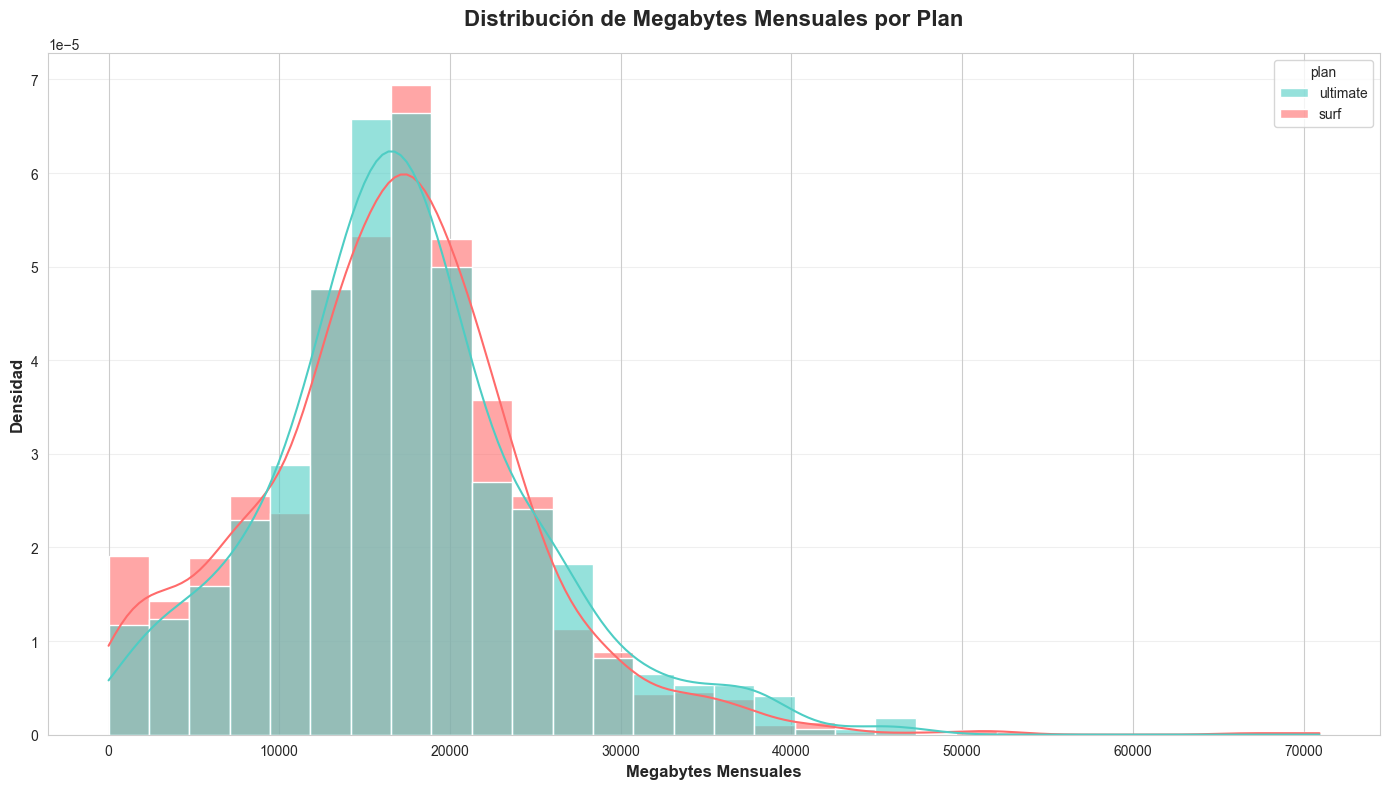

In [87]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
plt.figure(figsize=(14, 8))

# Histograma con curvas de densidad
sns.histplot(data=user_data, x='mb_used', hue='plan', 
             bins=30, kde=True, stat='density', common_norm=False,
             palette={'surf': '#FF6B6B', 'ultimate': '#4ECDC4'}, 
             alpha=0.6)

plt.title('Distribución de Megabytes Mensuales por Plan', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Megabytes Mensuales', fontsize=12, fontweight='bold')
plt.ylabel('Densidad', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
# Calcula la media y la varianza del trafico mensual de internet.
stats_by_plan_mb = user_data.groupby('plan')['mb_used'].agg([
    'count',   
    'mean',     
    'var',      
    'std',      
    'min',      
    'max'       
]).round(2)

print("Resumen estadístico:")
print(stats_by_plan_mb)

Resumen estadístico:
          count      mean          var      std  min       max
plan                                                          
surf       1573  16558.28  64216395.84  8013.51  0.0  70931.59
ultimate    720  17214.70  61652293.32  7851.90  0.0  46595.33


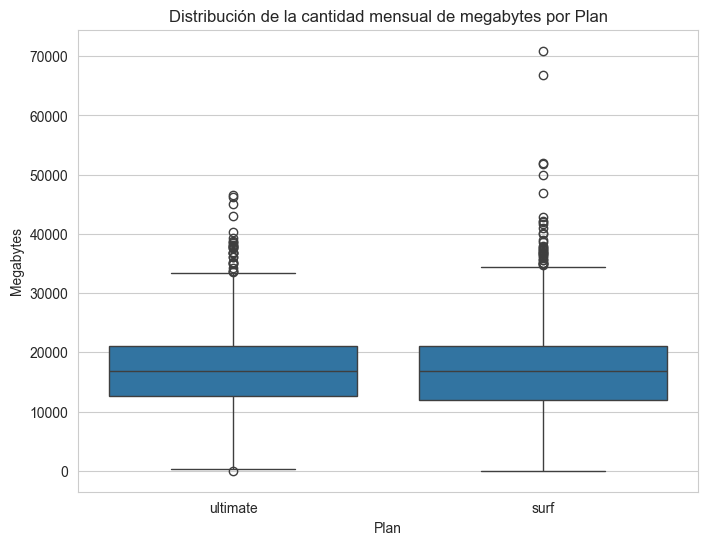

In [89]:
# Traza un diagrama de caja para visualizar la distribución del trafico mensual de internet
plt.figure(figsize=(8, 6))
sns.boxplot(data=user_data, x='plan', y='mb_used')
plt.title('Distribución de la cantidad mensual de megabytes por Plan')
plt.xlabel('Plan')
plt.ylabel('Megabytes')
plt.show()

   
Basándonos en los gráficos y el resumen estadístico, la conclusión principal es que, aunque los usuarios del plan ultimate consumen un poco más de megabytes en promedio (media de 17,214.70 MB) que los usuarios del plan surf (media de 16,558.28 MB), la distribución general del consumo es muy similar entre ambos planes. Los boxplots y el gráfico de densidad muestran que la mayoría de los usuarios de ambos planes se concentra en rangos de consumo de megabytes cercanos, con medianas (la línea dentro de la caja del boxplot) y rangos intercuartílicos parecidos. Sin embargo, el plan surf presenta una mayor dispersión en su consumo (mayor varianza y desviación estándar) y tiene valores atípicos de consumo máximo significativamente más altos (hasta 70,931.59 MB) que el plan ultimate (máximo de 46,595.33 MB), lo que indica que, a pesar de tener una media ligeramente inferior, algunos usuarios de surf alcanzan un consumo mensual extremadamente alto.


## Ingreso

<Figure size 1400x800 with 0 Axes>

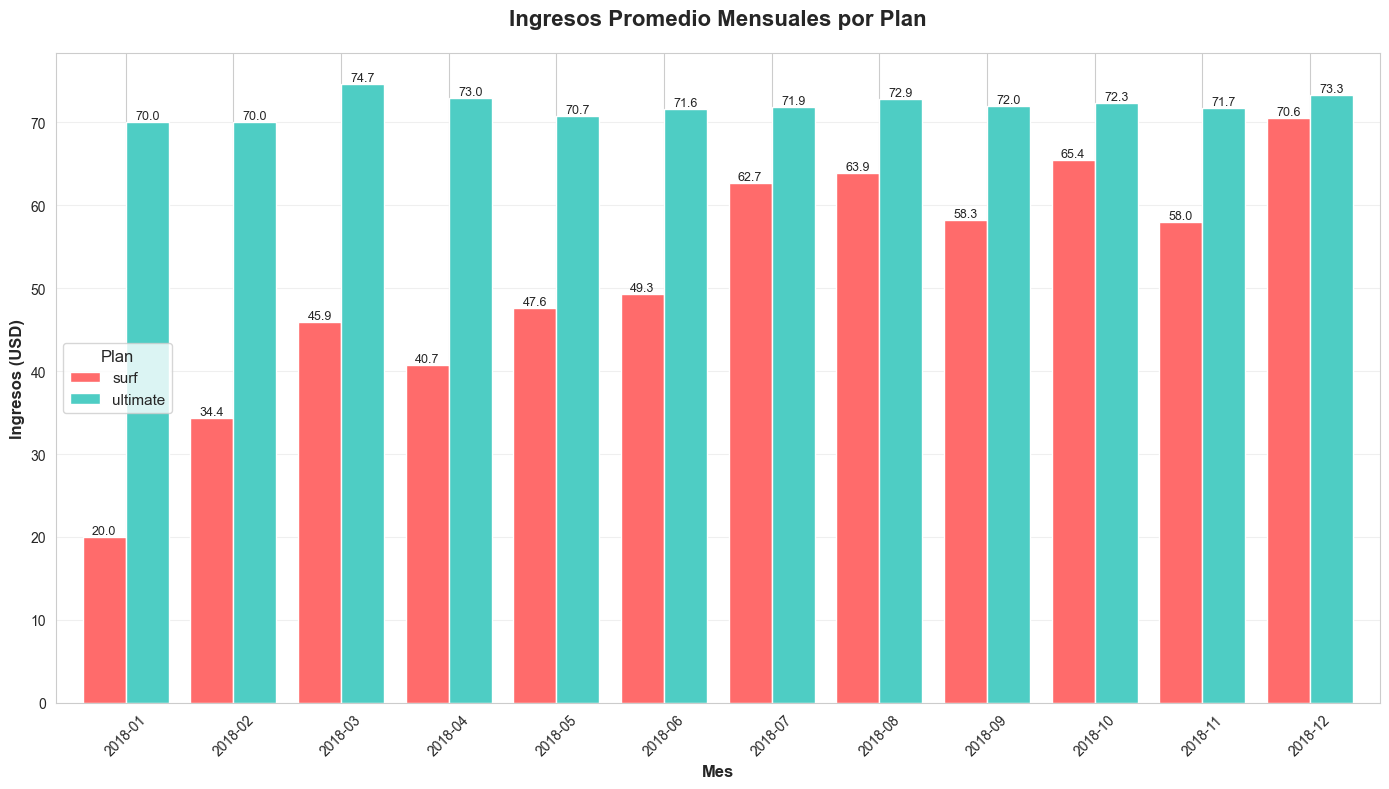

In [90]:
# Agrupar por plan y mes, calcular duración promedio
avg_duration_monthly_revenue = user_data.groupby(['plan', 'month'])['monthly_revenue'].mean().reset_index()

# Configurar el estilo
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Crear gráfico de barras agrupadas
avg_duration_mr_pivot = avg_duration_monthly_revenue.pivot(index='month', columns='plan', values='monthly_revenue')

# Crear el gráfico
ax = avg_duration_mr_pivot.plot(kind='bar', 
                            figsize=(14, 8),
                            color=['#FF6B6B', '#4ECDC4'],  
                            width=0.8)

# Personalizar el gráfico
plt.title('Ingresos Promedio Mensuales por Plan', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mes', fontsize=12, fontweight='bold')
plt.ylabel('Ingresos (USD)', fontsize=12, fontweight='bold')
plt.legend(title='Plan', title_fontsize=12, fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.tight_layout()
plt.show()

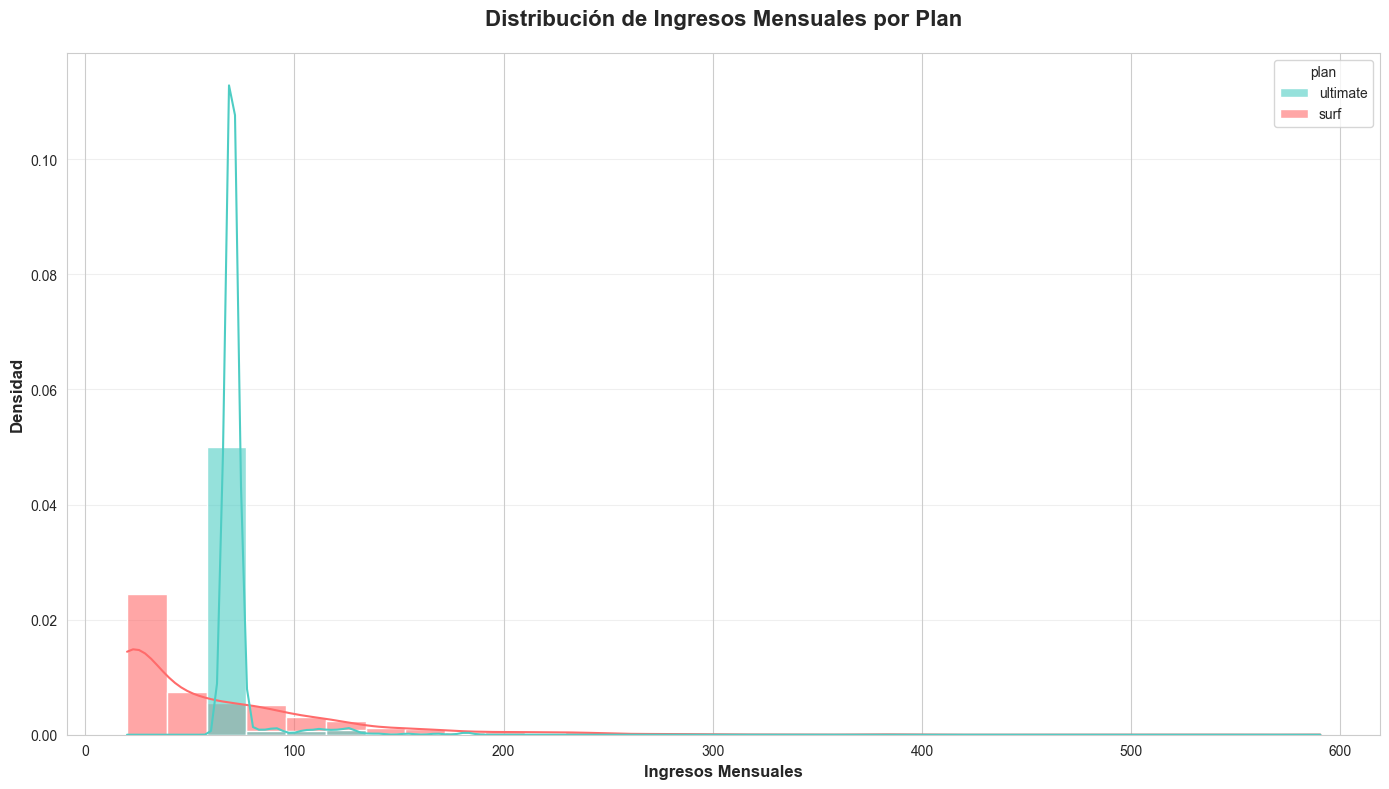

In [91]:
# Compara los ingresos pagados por usuarios por plan
plt.figure(figsize=(14, 8))

# Histograma con curvas de densidad
sns.histplot(data=user_data, x='monthly_revenue', hue='plan', 
             bins=30, kde=True, stat='density', common_norm=False,
             palette={'surf': '#FF6B6B', 'ultimate': '#4ECDC4'}, 
             alpha=0.6)

plt.title('Distribución de Ingresos Mensuales por Plan', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ingresos Mensuales', fontsize=12, fontweight='bold')
plt.ylabel('Densidad', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
# Calcula la media y la varianza del ingreso mensual por plan 
stats_by_plan_monthly_revenue = user_data.groupby('plan')['monthly_revenue'].agg([
    'count',   
    'mean',     
    'var',      
    'std',      
    'min',      
    'max'       
]).round(2)

print("Resumen estadístico:")
print(stats_by_plan_monthly_revenue)

Resumen estadístico:
          count   mean      var    std   min     max
plan                                                
surf       1573  60.71  3067.84  55.39  20.0  590.37
ultimate    720  72.31   129.85  11.40  70.0  182.00


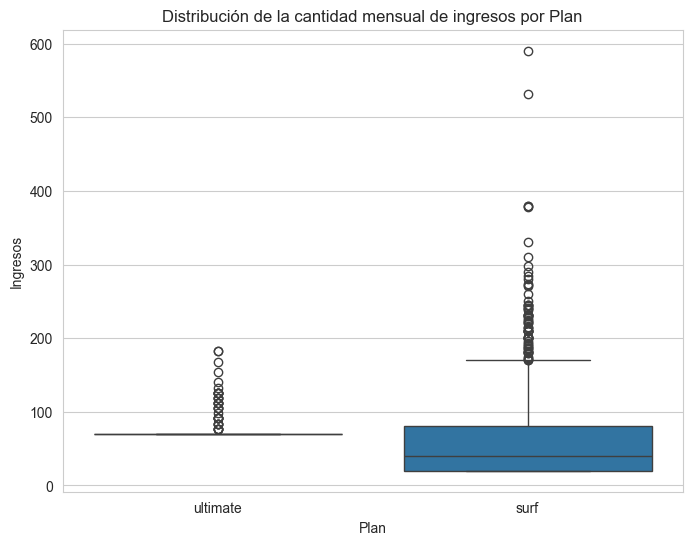

In [93]:
# Traza un diagrama de caja para visualizar la distribución del ingreso mensual por plan
plt.figure(figsize=(8, 6))
sns.boxplot(data=user_data, x='plan', y='monthly_revenue')
plt.title('Distribución de la cantidad mensual de ingresos por Plan')
plt.xlabel('Plan')
plt.ylabel('Ingresos')
plt.show()

Basado en las gráficas y estadísticas, se observa que el plan Ultimate genera un ingreso promedio mensual consistentemente mayor ($72.31) que el plan Surf ($60.33), y este patrón se mantiene a lo largo de todos los meses del año, como lo muestra el gráfico de ingresos promedio. Sin embargo, el plan Surf tiene una cantidad total de usuarios significativamente mayor (1573 vs. 720 para Ultimate), y aunque su ingreso promedio es menor, la variabilidad (Varianza: 3053.96 y Desviación Estándar: $55.26) e ingresos máximos ($588.64) son considerablemente más altos y dispersos que los de Ultimate (Varianza: 129.85, Desviación Estándar: $11.40, Máximo: $182.00). Esta mayor dispersión, confirmada por la distribución y el diagrama de caja, indica que mientras la mayoría de los usuarios de Ultimate pagan cerca del cargo fijo, los usuarios de Surf, aunque menos rentables en promedio, tienen el potencial de generar ingresos muy altos debido a cargos adicionales, y son la mayor fuente de clientes de la compañía.

## Prueba las hipótesis estadísticas

Probar que los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf son diferentes.

La hipotesis nula es que no hay diferencia en los ingresos promedio entre el plan ultimate y surf

La hipotesis alternativa es que si hay diferencia en los ingresos promedio entre el plan ultimate y surf

La prueba estadistica a realizar es un t test por ser dos muestras independientes 

Nivel de significancia de 5%

In [98]:
# Prueba las hipótesis
# Separar los ingresos por plan
ingresos_ultimate = user_data[user_data['plan'] == 'ultimate']['monthly_revenue']
ingresos_surf = user_data[user_data['plan'] == 'surf']['monthly_revenue']

# Estadísticas descriptivas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"Usuarios Ultimate: {len(ingresos_ultimate)}")
print(f"Usuarios Surf: {len(ingresos_surf)}")
print(f"Ingreso promedio Ultimate: ${ingresos_ultimate.mean():.2f}")
print(f"Ingreso promedio Surf: ${ingresos_surf.mean():.2f}")
print(f"Desviación estándar Ultimate: ${ingresos_ultimate.std():.2f}")
print(f"Desviación estándar Surf: ${ingresos_surf.std():.2f}")

# Definir hipótesis
print("\n=== HIPÓTESIS ===")
print("H₀: μ_Ultimate = μ_Surf (No hay diferencia en ingresos promedio)")
print("H₁: μ_Ultimate ≠ μ_Surf (Sí hay diferencia en ingresos promedio)")
print("Nivel de significancia: α = 0.05")

# Realizar prueba t de dos muestras independientes
alpha = 0.05
statistic, p_value = st.ttest_ind(ingresos_ultimate, ingresos_surf, equal_var=False)

print(f"\n=== RESULTADOS DE LA PRUEBA ===")
print(f"Estadístico t: {statistic:.4f}")
print(f"Valor p: {p_value:.10f}")
print(f"Nivel de significancia: {alpha}")

# Interpretación de resultados
print(f"\n=== INTERPRETACIÓN ===")
if p_value < alpha:
    print(f"p-value ({p_value:.10f}) < α ({alpha})")
    print("RECHAZAMOS H₀")
    print("Conclusión: Hay evidencia estadísticamente significativa de que")
    print("los ingresos promedio entre los planes Ultimate y Surf son diferentes.")
else:
    print(f"p-value ({p_value:.10f}) >= α ({alpha})")
    print("NO RECHAZAMOS H₀")
    print("Conclusión: No hay evidencia estadísticamente significativa de que")
    print("los ingresos promedio entre los planes sean diferentes.")

# Diferencia práctica
diferencia = ingresos_ultimate.mean() - ingresos_surf.mean()
print(f"\nDiferencia en ingresos promedio: ${diferencia:.2f}")


=== ESTADÍSTICAS DESCRIPTIVAS ===
Usuarios Ultimate: 720
Usuarios Surf: 1573
Ingreso promedio Ultimate: $72.31
Ingreso promedio Surf: $60.71
Desviación estándar Ultimate: $11.40
Desviación estándar Surf: $55.39

=== HIPÓTESIS ===
H₀: μ_Ultimate = μ_Surf (No hay diferencia en ingresos promedio)
H₁: μ_Ultimate ≠ μ_Surf (Sí hay diferencia en ingresos promedio)
Nivel de significancia: α = 0.05

=== RESULTADOS DE LA PRUEBA ===
Estadístico t: 7.9521
Valor p: 0.0000000000
Nivel de significancia: 0.05

=== INTERPRETACIÓN ===
p-value (0.0000000000) < α (0.05)
RECHAZAMOS H₀
Conclusión: Hay evidencia estadísticamente significativa de que
los ingresos promedio entre los planes Ultimate y Surf son diferentes.

Diferencia en ingresos promedio: $11.61


Probar que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.

La hipotesis nula es que no hay diferencia en los ingresos promedio entre los usuarios de la zona de NY-NY y otras regiones.

La hipotesis alternativa es que si hay diferencia en los ingresos promedio entre los usuarios de la zona de NY-NY y otras regiones.

La prueba estadistica a realizar es un t test por ser dos muestras independientes 

Nivel de significancia de 5%

In [95]:
# Prueba las hipótesis
# Fusión de los dataframes por user_id
df_combinado = user_data.merge(df_usuarios[['user_id', 'city']], on='user_id', how='left')

# Ver las primeras filas para verificar la fusión
print("DataFrame combinado con ingresos y ciudad:")
df_combinado.head()


DataFrame combinado con ingresos y ciudad:


,user_id,month,calls,minutes,messages,mb_used,plan,messages_included,mb_per_month_included,minutes_included,...,extra_minutes,extra_messages,gb_used,gb_included,extra_gb,cost_extra_minutes,cost_extra_messages,cost_extra_gb,monthly_revenue,city
0,1000,2018-12,16.0,124.0,11.0,1901.47,ultimate,1000,30720,3000,...,0.0,0.0,2.0,30.0,0.0,0.0,0.00,0.0,70.00,"Atlanta-Sandy Springs-Roswell, GA MSA"
1,1001,2018-08,27.0,182.0,30.0,6919.15,surf,50,15360,500,...,0.0,0.0,7.0,15.0,0.0,0.0,0.00,0.0,20.00,"Seattle-Tacoma-Bellevue, WA MSA"
2,1001,2018-09,49.0,315.0,44.0,13314.82,surf,50,15360,500,...,0.0,0.0,14.0,15.0,0.0,0.0,0.00,0.0,20.00,"Seattle-Tacoma-Bellevue, WA MSA"
3,1001,2018-10,65.0,393.0,53.0,22330.49,surf,50,15360,500,...,0.0,3.0,22.0,15.0,7.0,0.0,0.09,70.0,90.09,"Seattle-Tacoma-Bellevue, WA MSA"
4,1001,2018-11,64.0,426.0,36.0,18504.30,surf,50,15360,500,...,0.0,0.0,19.0,15.0,4.0,0.0,0.00,40.0,60.00,"Seattle-Tacoma-Bellevue, WA MSA"


In [96]:
# Crear una columna booleana para identificar usuarios de NY-NJ
# Buscamos 'NY' o 'NJ' en la columna 'city', ignorando mayúsculas/minúsculas.
# El método .str.contains() devuelve True si el patrón se encuentra en la cadena.
filtro_ny_nj = df_combinado['city'].str.contains('NY', case=False, na=False) | \
               df_combinado['city'].str.contains('NJ', case=False, na=False)

# Asignar el resultado a una nueva columna
df_combinado['es_ny_nj'] = filtro_ny_nj

# Verificar cuántos usuarios caen en cada grupo
print("\nConteo de usuarios por región:")
print(df_combinado['es_ny_nj'].value_counts())


Conteo de usuarios por región:
es_ny_nj
False    1774
True      519
Name: count, dtype: int64


In [99]:
#Separar los datos de ingresos para la prueba de hipótesis
# Ingreso promedio de los usuarios de NY-NJ
ingresos_ny_nj = df_combinado[df_combinado['es_ny_nj'] == True]['monthly_revenue']

# Ingreso promedio de los usuarios de otras regiones
ingresos_otras_regiones = df_combinado[df_combinado['es_ny_nj'] == False]['monthly_revenue']

# Estadísticas descriptivas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"Usuarios del área NY-NJ: {len(ingresos_ny_nj)}")
print(f"Usuarios otras regiones: {len(ingresos_otras_regiones)}")
print(f"Ingreso promedio usuarios del área NY-NJ: ${ingresos_ny_nj.mean():.2f}")
print(f"Ingreso promedio usuarios otras regiones: ${ingresos_otras_regiones.mean():.2f}")
print(f"Desviación estándar usuarios del área NY-NJ: ${ingresos_ny_nj.std():.2f}")
print(f"Desviación estándar usuarios otras regiones: ${ingresos_otras_regiones.std():.2f}")

# Definir hipótesis
print("\n=== HIPÓTESIS ===")
print("H₀: μ_Area NY-NJ = μ_Otras regiones (No hay diferencia en ingresos promedio)")
print("H₁: μ_Area NY-NJ ≠ μ_Otras regiones (Sí hay diferencia en ingresos promedio)")
print("Nivel de significancia: α = 0.05")

# Realizar prueba t de dos muestras independientes
alpha = 0.05
statistic, p_value = st.ttest_ind(ingresos_ny_nj, ingresos_otras_regiones, equal_var=False)

print(f"\n=== RESULTADOS DE LA PRUEBA ===")
print(f"Estadístico t: {statistic:.4f}")
print(f"Valor p: {p_value:.10f}")
print(f"Nivel de significancia: {alpha}")

# Interpretación de resultados
print(f"\n=== INTERPRETACIÓN ===")
if p_value < alpha:
    print(f"p-value ({p_value:.10f}) < α ({alpha})")
    print("RECHAZAMOS H₀")
    print("Conclusión: Hay evidencia estadísticamente significativa de que")
    print("los ingresos promedio entre el area de NY-NJ y otras regiones son diferentes.")
else:
    print(f"p-value ({p_value:.10f}) >= α ({alpha})")
    print("NO RECHAZAMOS H₀")
    print("Conclusión: No hay evidencia estadísticamente significativa de que")
    print("los ingresos promedio entre el area de NY-NJ y otras regiones sean diferentes.")

=== ESTADÍSTICAS DESCRIPTIVAS ===
Usuarios del área NY-NJ: 519
Usuarios otras regiones: 1774
Ingreso promedio usuarios del área NY-NJ: $63.37
Ingreso promedio usuarios otras regiones: $64.64
Desviación estándar usuarios del área NY-NJ: $47.62
Desviación estándar usuarios otras regiones: $46.34

=== HIPÓTESIS ===
H₀: μ_Area NY-NJ = μ_Otras regiones (No hay diferencia en ingresos promedio)
H₁: μ_Area NY-NJ ≠ μ_Otras regiones (Sí hay diferencia en ingresos promedio)
Nivel de significancia: α = 0.05

=== RESULTADOS DE LA PRUEBA ===
Estadístico t: -0.5378
Valor p: 0.5908330351
Nivel de significancia: 0.05

=== INTERPRETACIÓN ===
p-value (0.5908330351) >= α (0.05)
NO RECHAZAMOS H₀
Conclusión: No hay evidencia estadísticamente significativa de que
los ingresos promedio entre el area de NY-NJ y otras regiones sean diferentes.


## Conclusión general

Ambos planes, Surf y Ultimate, muestran un uso promedio mensual de minutos de llamada (404.76 y 406.19, respectivamente), mensajes (31.16 y 37.55) y megabytes de datos (16558.28 y 17214.70) sorprendentemente similares a nivel de la media, con el plan Ultimate mostrando ligeramente más uso en mensajes y datos. Sin embargo, el plan Surf tiene un mayor número de observaciones (1573 frente a 720 del Ultimate), lo que podría indicar una mayor popularidad o base de usuarios. La variabilidad (desviación estándar) en el uso de minutos de llamada y megabytes es alta y comparable entre ambos planes (221.66 vs 227.25 para minutos; 8013.51 vs 7851.90 para megabytes), y los boxplots confirman que ambas distribuciones están sesgadas hacia la derecha con muchos valores atípicos, especialmente en el uso de datos (megabytes) y mensajes, lo que sugiere que la mayoría de los usuarios se mantienen por debajo de los límites de sus planes, pero un subconjunto significativo excede los promedios. En cuanto a la tendencia temporal, el uso promedio de llamadas tiende a aumentar para ambos planes a lo largo del año. En resumen, si bien los promedios de uso son muy parecidos, el plan Ultimate parece atraer a usuarios que envían más mensajes, mientras que el plan Surf tiene una base de usuarios más grande y una mayor dispersión de uso de minutos y datos, con algunos usuarios alcanzando valores máximos más altos.

El análisis de los ingresos promedio entre el área NY-NJ y otras regiones no encontroˊ una diferencia estadıˊsticamente significativa, lo que sugiere que la ubicación geográfica no influye en el ingreso promedio del usuario. Sin embargo, el análisis por plan reveló una diferencia estadıˊsticamente significativa en los ingresos promedio entre los planes Ultimate ($72.31) y Surf ($60.33), con el plan Ultimate generando $11.99 maˊs en ingresos promedio. En resumen, mientras que la región geográfica no es un factor diferenciador de ingresos, el tipo de plan al que está suscrito el usuario sí lo es, siendo Ultimate el que mayor ingreso promedio genera.